In [1]:
import re, math, json, os, pickle
import numpy as np
import pandas as pd
import torch
import esm
import matplotlib.pyplot as plt
from scipy import stats


1. Load Everything

In [2]:
pfam          = pickle.load(open('pfam.pkl', 'rb'))
clinvar_sample = pd.read_csv('clinvar_sample.csv')
uid_mapping   = json.load(open('uid_mapping.json'))
sequences     = json.load(open('sequences.json'))
gene_mapping  = json.load(open('gene_mapping.json'))
model, alphabet = esm.pretrained.esm1b_t33_650M_UR50S()
model.eval()
batch_converter = alphabet.get_batch_converter()
print("All loaded!")

All loaded!


2. Parse FATHMM output

In [7]:
def parse_fathmm_rtf(path):
    results = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
    import re
    text = re.sub(r'\\[a-z]+\d*\s?', ' ', content)
    text = re.sub(r'[{}]', '', text)
    for line in text.split('\\\n'):
        parts = [p.strip() for p in line.split('\t')]
        if len(parts) < 6:
            continue
        try:
            if not parts[0].strip().isdigit():
                continue
            uid   = parts[2].strip()
            sub   = parts[3].strip()
            pred  = parts[4].strip()
            score = float(parts[5].strip())
            if not pred:
                continue
            results.append({'uid': uid, 'sub': sub, 'prediction': pred, 'fathmm': score})
        except:
            continue
    return pd.DataFrame(results)

fathmm_df = parse_fathmm_rtf('fathmm_output.rtf')
fathmm_df['key'] = fathmm_df['uid'] + '_' + fathmm_df['sub']

clinvar_sample['key'] = clinvar_sample.apply(
    lambda r: f"{uid_mapping.get(r['GeneSymbol'], '')}_{r['wt']}{int(r['pos'])}{r['mut']}", axis=1
)

merged = clinvar_sample.merge(fathmm_df[['key','fathmm','prediction']], on='key', how='inner')
print(f"Merged: {len(merged)} variants")



Merged: 954 variants


3. ESM-1b

In [5]:
def esm1b_score(seq, pos, wt, mut):
    idx = pos - 1
    start = max(0, idx - 510)
    end   = min(len(seq), idx + 511)
    seq_window = seq[start:end]
    local_idx  = idx - start
    
    masked = seq_window[:local_idx] + '<mask>' + seq_window[local_idx+1:]
    _, _, tokens = batch_converter([('p', masked)])
    with torch.no_grad():
        logits = model(tokens)['logits'][0, local_idx+1]
    lp = torch.log_softmax(logits, dim=-1)
    return (lp[alphabet.get_idx(mut)] - lp[alphabet.get_idx(wt)]).item()

def get_diff_vector(seq, pos, mut):
    idx = pos - 1
    start = max(0, idx - 510)
    end   = min(len(seq), idx + 511)
    seq_window = seq[start:end]
    local_idx  = idx - start
    
    mut_seq = seq_window[:local_idx] + mut + seq_window[local_idx+1:]
    _, _, t1 = batch_converter([('p', seq_window)])
    _, _, t2 = batch_converter([('p', mut_seq)])
    with torch.no_grad():
        e1 = model(t1, repr_layers=[33])['representations'][33][0, local_idx+1].numpy()
        e2 = model(t2, repr_layers=[33])['representations'][33][0, local_idx+1].numpy()
    return e2 - e1

print("Functions redefined!")

esm1b_results = {}

if os.path.exists('esm1b_results.pkl'):
    esm1b_results = pickle.load(open('esm1b_results.pkl', 'rb'))

for i, (_, row) in enumerate(merged.iterrows()):
    key = f"{row['GeneSymbol']}_{row['wt']}{int(row['pos'])}{row['mut']}"
    

    if key in esm1b_results:
        continue
    
    seq = sequences.get(row['GeneSymbol'])
    if not seq or int(row['pos']) > len(seq):
        continue
    
    if i % 50 == 0:
        print(f'[{i}/{len(merged)}]')
        pickle.dump(esm1b_results, open('esm1b_results.pkl', 'wb'))
    
    try:
        score = esm1b_score(seq, int(row['pos']), row['wt'], row['mut'])
        diff  = get_diff_vector(seq, int(row['pos']), row['mut'])
        esm1b_results[key] = {'score': score, 'diff': diff}
    except Exception as e:
        print(f'Error at {key}: {e}')
        continue

pickle.dump(esm1b_results, open('esm1b_results.pkl', 'wb'))
print(f'Done: {len(esm1b_results)} variants')

Functions redefined!
[0/954]
[50/954]
[100/954]
[150/954]
[200/954]
[250/954]
[300/954]
[350/954]
[400/954]
[450/954]
[500/954]
[550/954]
[600/954]
[650/954]
[700/954]
[750/954]
[800/954]
[850/954]
[900/954]
[950/954]
Done: 954 variants


4. Classify

In [ ]:
merged['esm1b'] = merged['key2'].map(
    lambda k: esm1b_results[k]['score'] if k in esm1b_results else None
)
merged['diff'] = merged['key2'].map(
    lambda k: esm1b_results[k]['diff'] if k in esm1b_results else None
)

merged = merged.dropna(subset=['esm1b'])
print(f"After merge: {len(merged)} variants")
print(merged[['GeneSymbol', 'fathmm', 'esm1b', 'label']].head())

FATHMM_THRESHOLD = -1.5
ESM1B_THRESHOLD  = -7.5

merged['fathmm_pred'] = (merged['fathmm'] <= FATHMM_THRESHOLD).astype(int)
merged['esm1b_pred']  = (merged['esm1b']  <= ESM1B_THRESHOLD).astype(int)

def get_group(row):
    fp = row['fathmm_pred']
    ep = row['esm1b_pred']
    tl = row['label']
    if fp == tl and ep == tl:  return 'C'  # Both Right
    if fp != tl and ep == tl:  return 'A'  # FATHMM wrong, ESM-1b right
    if fp == tl and ep != tl:  return 'B'  # FATHMM right, ESM-1b wrong
    return 'D'                              # Both wrong

merged['group'] = merged.apply(get_group, axis=1)
print(merged['group'].value_counts())
print(merged[['GeneSymbol','wt','pos','mut','fathmm','esm1b','label','group']].head(20))

After merge: 954 variants
  GeneSymbol  fathmm     esm1b  label
0      A2ML1    1.17 -2.396614      0
1      A2ML1    1.63  0.902358      0
2      A2ML1    0.87 -3.120776      0
3      A2ML1    1.40 -0.052885      0
4      A2ML1    1.77 -0.295898      0
group
C    607
A    189
B    120
D     38
Name: count, dtype: int64
   GeneSymbol wt   pos mut  fathmm      esm1b  label group
0       A2ML1  R  1122   W    1.17  -2.396614      0     C
1       A2ML1  M  1257   V    1.63   0.902358      0     C
2       A2ML1  R  1359   H    0.87  -3.120776      0     C
3       A2ML1  N  1263   K    1.40  -0.052885      0     C
4       A2ML1  A   751   V    1.77  -0.295898      0     C
5       ABCA1  S  1376   G   -3.03  -5.580711      0     A
6       ABCA1  V   825   I   -1.99   2.383123      0     A
7       ABCA1  G   216   D   -2.28  -0.590539      0     A
8       ABCA1  V   771   M   -2.09   1.706086      0     A
9       ABCA1  N  1800   H   -2.34  -6.001763      1     B
10     ABCA12  R   986   W   

5. Statistical Analysis

In [13]:
valid   = merged.dropna(subset=['diff'])
X       = np.vstack(valid['diff'].values)
group_A = X[valid['group'] == 'A']
group_B = X[valid['group'] == 'B']
group_C = X[valid['group'] == 'C']

print(f"\nType A (FATHMM wrong, ESM-1b correct): {len(group_A)}")
print(f"Type B (FATHMM correct, ESM-1b wrong): {len(group_B)}")
print(f"Type C (both correct):                 {len(group_C)}")

p_values = []
for dim in range(X.shape[1]):
    groups = [g[:, dim] for g in [group_A, group_B, group_C] if len(g) > 0]
    if len(groups) >= 2:
        _, p = stats.kruskal(*groups)
    else:
        p = 1.0
    p_values.append(p)

p_values  = np.array(p_values)
sig_dims  = np.where(p_values < 0.05)[0]
print(f"\nSignificant dimensions (p < 0.05): {len(sig_dims)}")
print(f"Top 10 dims: {sig_dims[np.argsort(p_values[sig_dims])][:10]}")


Type A (FATHMM wrong, ESM-1b correct): 189
Type B (FATHMM correct, ESM-1b wrong): 120
Type C (both correct):                 607

Significant dimensions (p < 0.05): 338
Top 10 dims: [ 206  561 1237  331  103 1072   65  763 1031  928]


6. Plots

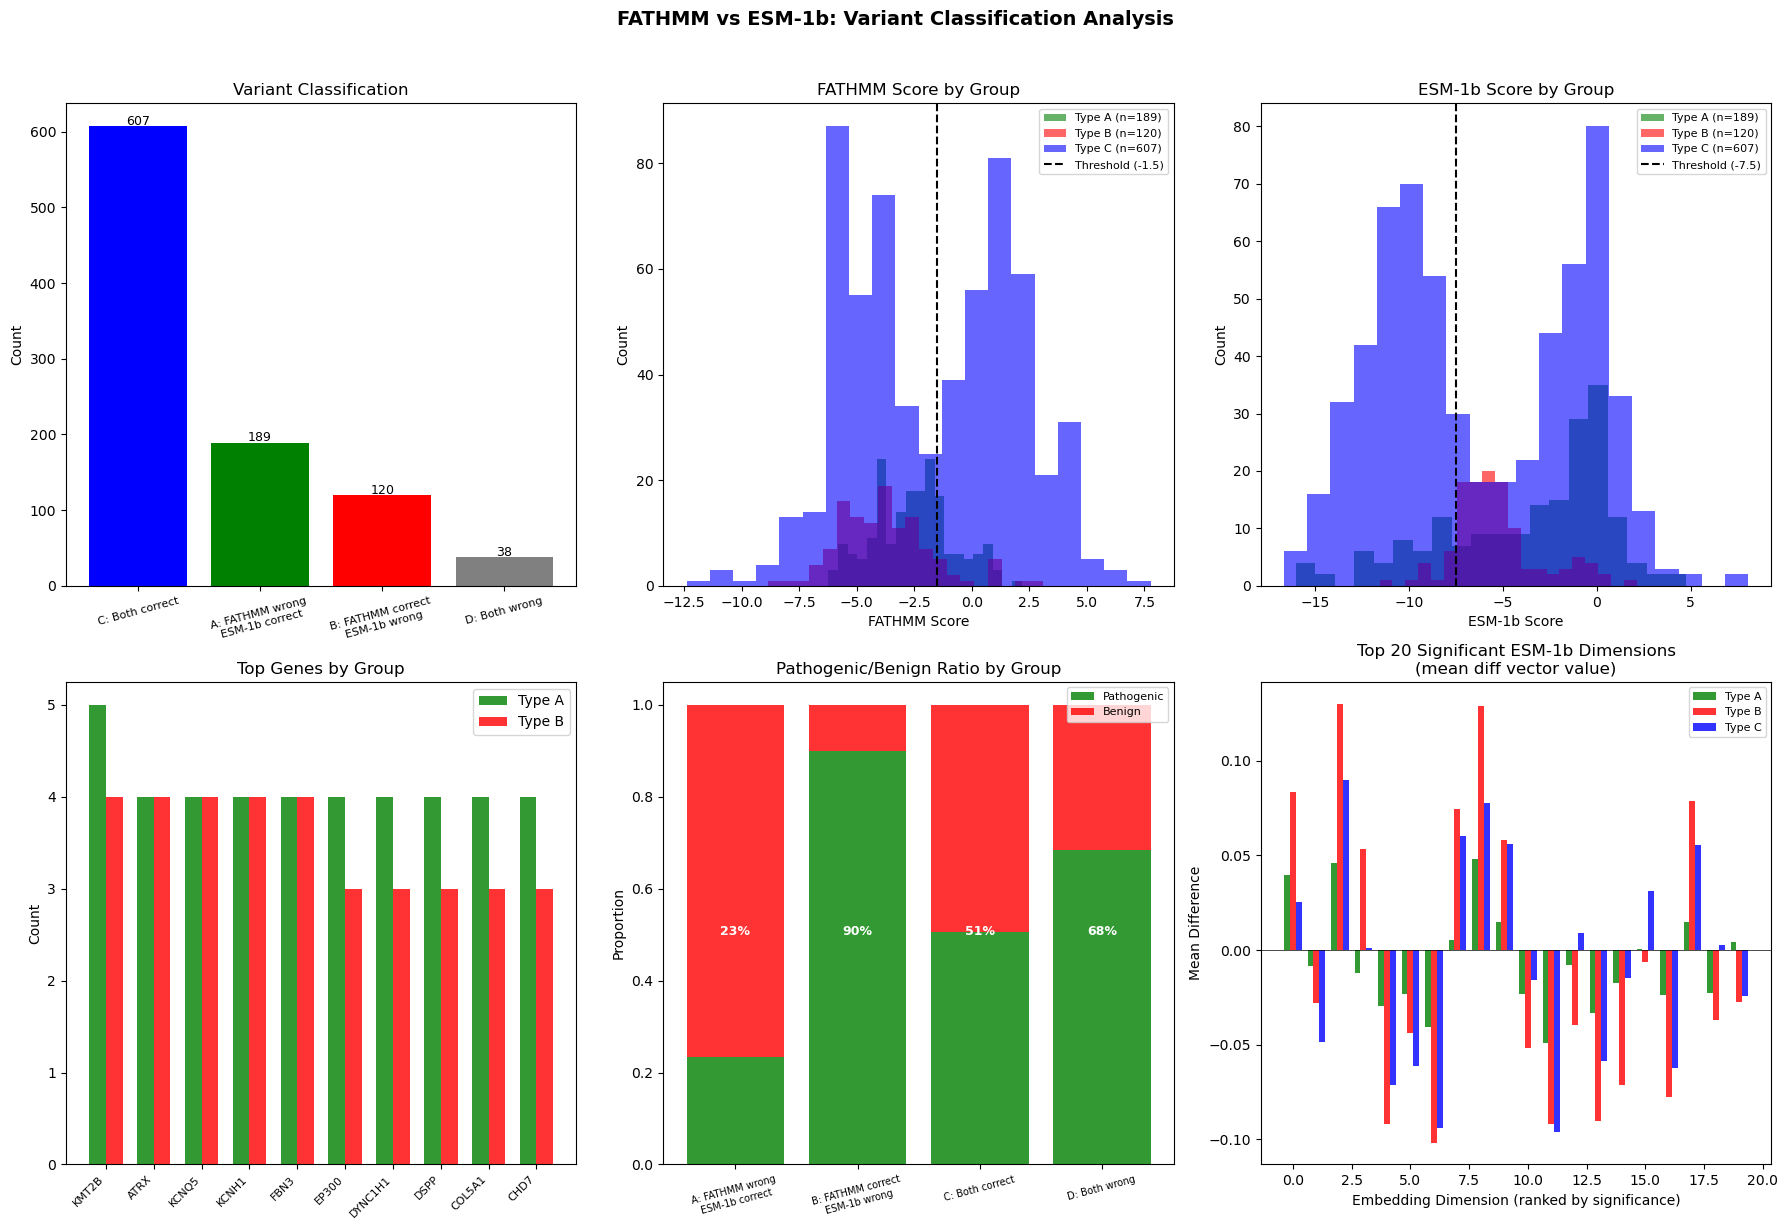

Saved to analysis_plots.png


In [21]:
fig = plt.figure(figsize=(18, 12))

#Group distribution
ax1 = fig.add_subplot(2, 3, 1)
counts = merged['group'].value_counts().reindex(['C','A','B','D'])
colors = {'A':'green','B':'red','C':'blue','D':'gray'}
labels = {'C':'C: Both correct','A':'A: FATHMM wrong\nESM-1b correct',
          'B':'B: FATHMM correct\nESM-1b wrong','D':'D: Both wrong'}
ax1.bar([labels[g] for g in counts.index], counts.values,
        color=[colors[g] for g in counts.index])
ax1.set_title('Variant Classification')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', labelsize=8, rotation=15)
for i, v in enumerate(counts.values):
    ax1.text(i, v + 2, str(v), ha='center', fontsize=9)

#FATHMM score by group
ax2 = fig.add_subplot(2, 3, 2)
for g, c in [('A','green'),('B','red'),('C','blue')]:
    subset = merged[merged['group']==g]
    ax2.hist(subset['fathmm'], bins=20, alpha=0.6, color=c,
             label=f'Type {g} (n={len(subset)})')
ax2.axvline(x=-1.5, color='black', linestyle='--', label='Threshold (-1.5)')
ax2.set_title('FATHMM Score by Group')
ax2.set_xlabel('FATHMM Score')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)

#ESM-1b score by group
ax3 = fig.add_subplot(2, 3, 3)
for g, c in [('A','green'),('B','red'),('C','blue')]:
    subset = merged[merged['group']==g]
    ax3.hist(subset['esm1b'], bins=20, alpha=0.6, color=c,
             label=f'Type {g} (n={len(subset)})')
ax3.axvline(x=-7.5, color='black', linestyle='--', label='Threshold (-7.5)')
ax3.set_title('ESM-1b Score by Group')
ax3.set_xlabel('ESM-1b Score')
ax3.set_ylabel('Count')
ax3.legend(fontsize=8)

#Top genes in Type A and B
ax4 = fig.add_subplot(2, 3, 4)
type_a_genes = merged[merged['group']=='A']['GeneSymbol'].value_counts().head(10)
type_b_genes = merged[merged['group']=='B']['GeneSymbol'].value_counts().head(10)

x = np.arange(10)
w = 0.35
ax4.bar(x - w/2, type_a_genes.values, w, label='Type A', color='green', alpha=0.8)
ax4.bar(x + w/2, type_b_genes.values, w, label='Type B', color='red', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(type_a_genes.index, rotation=45, ha='right', fontsize=8)
ax4.set_title('Top Genes by Group')
ax4.set_ylabel('Count')
ax4.legend()

#Pathogenic/Benign ratio by group
ax5 = fig.add_subplot(2, 3, 5)
groups = ['A', 'B', 'C', 'D']
path_ratio = [merged[merged['group']==g]['label'].mean() for g in groups]
benign_ratio = [1 - r for r in path_ratio]

x = np.arange(len(groups))
ax5.bar(x, path_ratio, label='Pathogenic', color='green', alpha=0.8)
ax5.bar(x, benign_ratio, bottom=path_ratio, label='Benign', color='red', alpha=0.8)
ax5.set_xticks(x)
ax5.set_xticklabels([labels[g] for g in groups], fontsize=7, rotation=15)
ax5.set_title('Pathogenic/Benign Ratio by Group')
ax5.set_ylabel('Proportion')
ax5.legend(fontsize=8)
for i, (p, b) in enumerate(zip(path_ratio, benign_ratio)):
    ax5.text(i, 0.5, f'{p:.0%}', ha='center', color='white', fontsize=9, fontweight='bold')

# ── 6. Significant ESM-1b dimensions ─────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
valid   = merged.dropna(subset=['diff'])
X       = np.vstack(valid['diff'].values)
group_A = X[valid['group']=='A']
group_B = X[valid['group']=='B']
group_C = X[valid['group']=='C']

p_values = []
for dim in range(X.shape[1]):
    groups_data = [g[:, dim] for g in [group_A, group_B, group_C] if len(g) > 0]
    if len(groups_data) >= 2:
        _, p = stats.kruskal(*groups_data)
    else:
        p = 1.0
    p_values.append(p)

p_values = np.array(p_values)
top_dims = np.argsort(p_values)[:20]

# Mean diff vector value per group for top 20 dims
a_means = group_A[:, top_dims].mean(axis=0) if len(group_A) > 0 else np.zeros(20)
b_means = group_B[:, top_dims].mean(axis=0) if len(group_B) > 0 else np.zeros(20)
c_means = group_C[:, top_dims].mean(axis=0) if len(group_C) > 0 else np.zeros(20)

x = np.arange(20)
w = 0.25
ax6.bar(x - w, a_means, w, label='Type A', color='green', alpha=0.8)
ax6.bar(x,     b_means, w, label='Type B', color='red', alpha=0.8)
ax6.bar(x + w, c_means, w, label='Type C', color='blue', alpha=0.8)
ax6.set_title('Top 20 Significant ESM-1b Dimensions\n(mean diff vector value)')
ax6.set_xlabel('Embedding Dimension (ranked by significance)')
ax6.set_ylabel('Mean Difference')
ax6.legend(fontsize=8)
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.suptitle('FATHMM vs ESM-1b: Variant Classification Analysis', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to analysis_plots.png")

In [23]:
extent = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('plot1_group_distribution.png', bbox_inches=extent, dpi=150)

#ax2
extent = ax2.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('plot2_fathmm_scores.png', bbox_inches=extent, dpi=150)

#ax3
extent = ax3.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('plot3_esm1b_scores.png', bbox_inches=extent, dpi=150)

#ax4
extent = ax4.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('plot4_top_genes.png', bbox_inches=extent, dpi=150)

#ax5
extent = ax5.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('plot5_label_ratio.png', bbox_inches=extent, dpi=150)

#ax6
extent = ax6.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('plot6_esm1b_dimensions.png', bbox_inches=extent, dpi=150)

8. Further Analysis

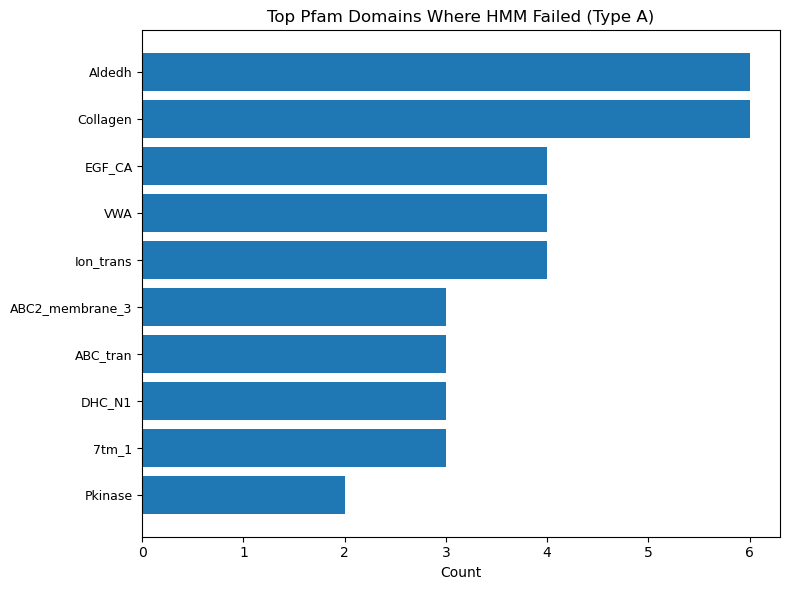

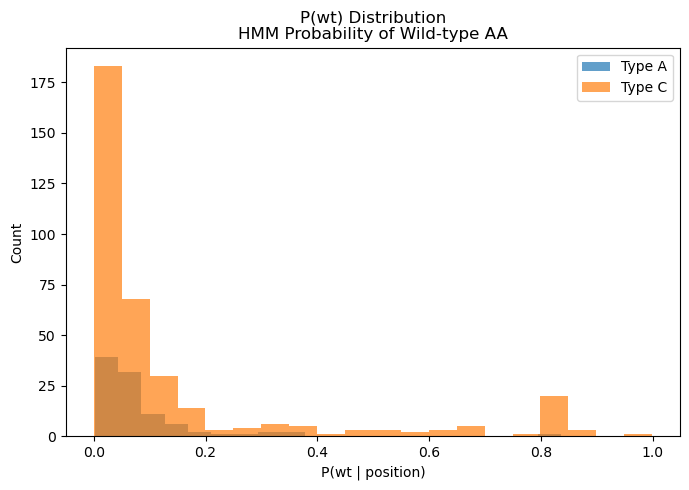

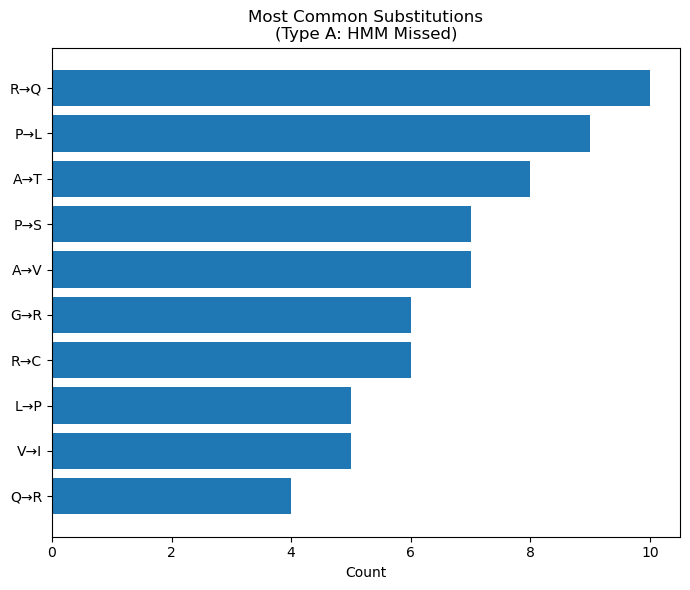

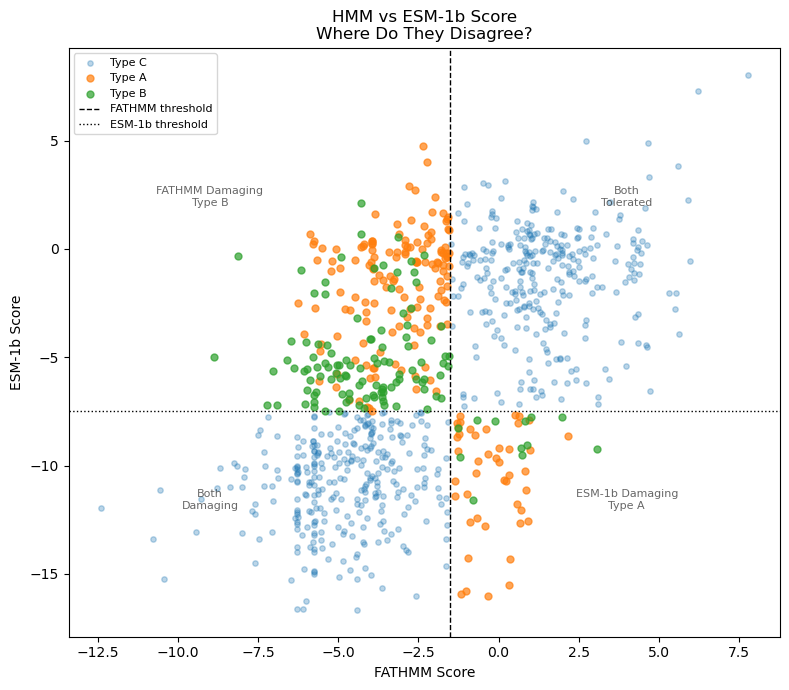

In [ ]:
#Domain failure
fig, ax = plt.subplots(figsize=(8, 6))
domain_a = type_a['domain'].value_counts().head(10)
ax.barh(domain_a.index[::-1], domain_a.values[::-1])
ax.set_title('Top Pfam Domains Where HMM Failed (Type A)')
ax.set_xlabel('Count')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('plot7_domain_failure.png', dpi=150)
plt.show()

#P(wt) distribution
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(type_a['p_wt'].dropna(), bins=20, alpha=0.7, label='Type A')
ax.hist(type_c['p_wt'].dropna(), bins=20, alpha=0.7, label='Type C')
ax.set_title('P(wt) Distribution\nHMM Probability of Wild-type AA')
ax.set_xlabel('P(wt | position)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('plot8_pwt_distribution.png', dpi=150)
plt.show()

#Substitution patterns
fig, ax = plt.subplots(figsize=(7, 6))
mut_type_a = type_a['mut_type'].value_counts().head(10)
ax.barh(mut_type_a.index[::-1], mut_type_a.values[::-1])
ax.set_title('Most Common Substitutions\n(Type A: HMM Missed)')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('plot9_substitutions.png', dpi=150)
plt.show()

#HMM vs ESM-1b scatter
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(type_c['fathmm'], type_c['esm1b'], alpha=0.3, s=15, label='Type C')
ax.scatter(type_a['fathmm'], type_a['esm1b'], alpha=0.7, s=25, label='Type A')
ax.scatter(type_b['fathmm'], type_b['esm1b'], alpha=0.7, s=25, label='Type B')
ax.axvline(x=-1.5, color='black', linestyle='--', linewidth=1, label='FATHMM threshold')
ax.axhline(y=-7.5, color='black', linestyle=':',  linewidth=1, label='ESM-1b threshold')
ax.text(4,    2,   'Both\nTolerated',         ha='center', fontsize=8, alpha=0.6)
ax.text(-9,   2,   'FATHMM Damaging\nType B', ha='center', fontsize=8, alpha=0.6)
ax.text(4,   -12,  'ESM-1b Damaging\nType A', ha='center', fontsize=8, alpha=0.6)
ax.text(-9,  -12,  'Both\nDamaging',           ha='center', fontsize=8, alpha=0.6)
ax.set_xlabel('FATHMM Score')
ax.set_ylabel('ESM-1b Score')
ax.set_title('HMM vs ESM-1b Score\nWhere Do They Disagree?')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('plot10_scatter.png', dpi=150)
plt.show()